# Make Estimation File

Script to create a mode choice estimation file for a chocie of TNC, transit or walk.  (or potentiall a binary model of TNC vs the better of transit/walk.)  Use 2024 CMAP survey.  


In [59]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.reset_option('display.float_format')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from statsmodels.stats.weightstats import DescrStatsW

from codebook import Codebook
cb = Codebook()

In [2]:
## start with just the survey data
trip_linked = pd.read_csv('data/trip_linked_2024.csv',
    dtype={'o_tract_2020': 'Int64', 'd_tract_2020': 'Int64'})
trip_linked

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,45,0.0,2024-05-21,12,13,0.0,544,0.338027,28,82.0,0,0,0,17031081500,17031081403,1,0,0,0,0,0,0,0,0,0,33,10,150,12,4,2,0,0,2400012401010102,2,15,0,1,1853.792592,24000124010101,1
2,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1
3,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,59,0.0,2024-05-21,14,15,0.0,514,0.319386,16,NaN,0,0,0,17031320101,17031320101,1,0,0,0,0,0,0,0,0,0,33,10,1,1,4,4,0,1,2400012401010104,4,15,0,1,1853.792592,24000124010101,1
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60057,24601170,2460117004,4,246011700401,1,2460117000102,29,2025-06-04,18,20,0.0,2025-06-04,18,30,0.0,2230,1.385661,10,10.0,0,0,0,17197880318,17197880317,1,0,1,1,0,0,0,0,0,0,51,9,102,8,4,2,0,0,2460117004010202,2,8,1,3,308.896900,24601170040102,2
60058,24601170,2460117004,4,246011700401,1,2460117000103,30,2025-06-04,18,40,0.0,2025-06-04,18,45,0.0,381,0.236743,5,30.0,0,0,0,17197880317,17197880317,1,0,1,1,0,0,0,0,0,0,102,8,99,10,4,3,0,0,2460117004010203,3,8,1,3,308.896900,24601170040102,2
60059,24601170,2460117004,4,246011700401,1,2460117000104,31,2025-06-04,19,15,0.0,2025-06-04,19,40,0.0,23964,14.890576,25,NaN,0,0,0,17197880317,17093890703,1,0,1,1,0,0,0,0,0,0,99,10,1,1,4,4,0,1,2460117004010204,4,8,0,3,308.896900,24601170040102,2
60060,24601172,2460117201,1,246011720101,1,-1,NaN,2025-06-04,8,0,0.0,2025-06-04,8,1,0.0,18884,11.734003,1,39.0,1,0,0,17097864511,17031803300,1,0,0,0,0,0,0,0,0,0,1,1,10,2,2,1,1,0,2460117201010101,1,10,1,1,1494.058248,24601172010101,1


First we want to understand what the data represent and which weights to use.  Start by looking through cmap_hts_dataset_guide.html, particularly the section on weights.  

After reviewing the documenation, it -appears- that the trips are expanded to represent typical weekday (Tue-Thu) conditions.  We want to use the linked trips, and will use the linked trip weights.  


To help make these more readable, in a way analogous to what is shown for R in the documentation, I created a phython helper class.  This usage is as follows: 

``` python 
from codebook import Codebook
cb = Codebook()

# R: factor(transit_freq, levels=..., labels=...)
person["transit_freq_f"] = cb.as_categorical(person["transit_freq"], "person", "transit_freq")

# Lighter: just swap codes for labels
person["transit_freq_label"] = cb.decode(person["transit_freq"], "person", "transit_freq")

# Lookup a variable's description / data type / skip logic
cb.describe("person", "transit_freq")

# Browse everything documented for a table
cb.variables_in("person")
```

In [3]:
# Let's look at an example summarizing the frequency of trip modes

trip_linked['linked_trip_mode_labeled'] = cb.decode(trip_linked['linked_trip_mode'], 'trip_linked', 'linked_trip_mode')

pd.DataFrame({
    'count':    trip_linked['linked_trip_mode_labeled'].value_counts(),
    'weighted': trip_linked.groupby('linked_trip_mode_labeled')['linked_trip_weight'].sum(),
}).sort_index().round()


,count,weighted
linked_trip_mode_labeled,,
Bike,1235,359491.0
Drive to bus,51,55563.0
Drive to rail,267,321613.0
HOV (2 people),11973,6838662.0
HOV (3+ people),9841,5282716.0
Long distance mode,43,22065.0
Micromobility,51,13375.0
Not imputable,1113,111951.0
Other,311,201671.0


In [4]:
# now let's recode these into a shorter set of modes:

mode_recode = {
	-1 : 'not_imputable',  # Not imputable
	1  : 'school_bus',     # School bus
	2  : 'transit',        # Drive to ferry
	3  : 'transit',        # Drive to rail
	4  : 'transit',        # Drive to bus
	5  : 'transit',        # Walk to ferry
	6  : 'transit',        # Walk to rail
	7  : 'transit',        # Walk to bus
	8  : 'car',            # HOV (3+ people)
	9  : 'car',            # HOV (2 people)
	10 : 'car',            # SOV
	11 : 'bike',           # Bike
	12 : 'bike',           # Micromobility
	13 : 'tnc',            # Taxi
	14 : 'tnc',            # TNC
	15 : 'walk',           # Walk
	16 : 'other',          # Long distance mode
	17 : 'other',          # Other
	18 : 'transit'         # Transit
}

trip_linked['mode'] = trip_linked['linked_trip_mode'].map(mode_recode)

In [5]:
# now check that it makes sense
pd.DataFrame({
    'count':    trip_linked['mode'].value_counts(),
    'weighted': trip_linked.groupby('mode')['linked_trip_weight'].sum(),
}).sort_index().round()

,count,weighted
mode,,
bike,1286,372867.0
car,42958,24928666.0
not_imputable,1113,111951.0
other,354,223736.0
school_bus,881,671795.0
tnc,853,393457.0
transit,2836,2123921.0
walk,9781,3898687.0


In [6]:
# Now let's join in the place names so we can identify which trips start and end in Chicago, and summarize by districts. 

# load the lookup
df_tract_district = pd.read_csv('data/tract_2020_district.csv')   
tract_to_district = dict(zip(df_tract_district['GEOID'], df_tract_district['RH_Zone']))

trip_linked['o_district'] = trip_linked['o_tract_2020'].map(tract_to_district)
trip_linked['d_district'] = trip_linked['d_tract_2020'].map(tract_to_district)

trip_linked

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,o_district,d_district
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,45,0.0,2024-05-21,12,13,0.0,544,0.338027,28,82.0,0,0,0,17031081500,17031081403,1,0,0,0,0,0,0,0,0,0,33,10,150,12,4,2,0,0,2400012401010102,2,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
2,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
3,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,59,0.0,2024-05-21,14,15,0.0,514,0.319386,16,NaN,0,0,0,17031320101,17031320101,1,0,0,0,0,0,0,0,0,0,33,10,1,1,4,4,0,1,2400012401010104,4,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60057,24601170,2460117004,4,246011700401,1,2460117000102,29,2025-06-04,18,20,0.0,2025-06-04,18,30,0.0,2230,1.385661,10,10.0,0,0,0,17197880318,17197880317,1,0,1,1,0,0,0,0,0,0,51,9,102,8,4,2,0,0,2460117004010202,2,8,1,3,308.896900,24601170040102,2,HOV (3+ people),car,External,External
60058,24601170,2460117004,4,246011700401,1,2460117000103,30,2025-06-04,18,40,0.0,2025-06-04,18,45,0.0,381,0.236743,5,30.0,0,0,0,17197880317,17197880317,1,0,1,1,0,0,0,0,0,0,102,8,99,10,4,3,0,0,2460117004010203,3,8,1,3,308.896900,24601170040102,2,HOV (3+ people),car,External,External
60059,24601170,2460117004,4,246011700401,1,2460117000104,31,2025-06-04,19,15,0.0,2025-06-04,19,40,0.0,23964,14.890576,25,NaN,0,0,0,17197880317,17093890703,1,0,1,1,0,0,0,0,0,0,99,10,1,1,4,4,0,1,2460117004010204,4,8,0,3,308.896900,24601170040102,2,HOV (3+ people),car,External,External
60060,24601172,2460117201,1,246011720101,1,-1,NaN,2025-06-04,8,0,0.0,2025-06-04,8,1,0.0,18884,11.734003,1,39.0,1,0,0,17097864511,17031803300,1,0,0,0,0,0,0,0,0,0,1,1,10,2,2,1,1,0,2460117201010101,1,10,1,1,1494.058248,24601172010101,1,SOV,car,External,External


In [7]:
# make the districts an ordered categorical for a nice display
order = ['Downtown', 'Tourist', 'Other', 'Airport', 'External']
cat = pd.CategoricalDtype(order, ordered=True)

trip_linked['o_district'] = trip_linked['o_district'].astype(cat)
trip_linked['d_district'] = trip_linked['d_district'].astype(cat)

In [8]:
# next we filter to exclude trips we don't have in our TNC data.

print("Keep only trips with origin and destination in Chicago")
trips_before = len(trip_linked)
trip_linked = trip_linked[(trip_linked['o_district'] != 'External') & (trip_linked['d_district'] != 'External') ].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Keep only trips with origin and destination in Chicago
Before: 60062 After: 22003


In [9]:
# next we filter to exclude trips we don't have in our TNC data.
# We could re-consider whether to drop the airport trips.  It's not obvious it's necessary to drop them, but there are not many here. 

print("Drop trips to/from airports")
trips_before = len(trip_linked)
trip_linked = trip_linked[(trip_linked['o_district'] != 'Airport') & (trip_linked['d_district'] != 'Airport') ].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Drop trips to/from airports
Before: 22003 After: 21824


In [10]:
# next we filter to exclude trips we don't have in our TNC data.

print("Keep only trips on the three modes we care about")
modes = ['tnc', 'transit', 'walk']

trips_before = len(trip_linked)
trip_linked = trip_linked[trip_linked['mode'].isin(modes)].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))


Keep only trips on the three modes we care about
Before: 21824 After: 9915


In [11]:
# next we filter to exclude trips we don't have in our TNC data.

print("Keep walk trips only if they are > 0.5 miles, because they don't really compete with TNCs if they are shorter than that.")

trips_before = len(trip_linked)
trip_linked = trip_linked[((trip_linked['mode']=='walk') & (trip_linked['distance_miles']>=0.5)) | (trip_linked['mode']!='walk')].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))


Keep walk trips only if they are > 0.5 miles, because they don't really compete with TNCs if they are shorter than that.
Before: 9915 After: 5446


In [12]:
# next we filter to exclude trips we don't have in our TNC data.

print("Drop loop tours.")
tour = pd.read_csv('data/tour_2024.csv')
trip_linked = trip_linked.merge(tour, on='tour_id', how='left', suffixes=['', '_tour'])

trips_before = len(trip_linked)
trip_linked = trip_linked[trip_linked['tour_purpose']!=14].copy()

print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Drop loop tours.
Before: 5446 After: 4982


In [13]:
# next we filter to exclude trips we don't have in our TNC data.

print("Drop if the distance is zero.")
trips_before = len(trip_linked)
trip_linked = trip_linked[trip_linked['distance_miles']>0].copy()

print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Drop if the distance is zero.
Before: 4982 After: 4906


In [14]:
# next we filter to exclude trips we don't have in our TNC data.

print("Drop if the origin or destination Census tract is missing.")
trips_before = len(trip_linked)
trip_linked = trip_linked[(trip_linked['o_tract_2020']!=995) & (trip_linked['d_tract_2020']!=995)].copy()

print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Drop if the origin or destination Census tract is missing.
Before: 4906 After: 4663


In [15]:
# Convert the column to datetime and crate a day-of-week column
trip_linked['depart_date'] = pd.to_datetime(trip_linked['depart_date'])
trip_linked['day_of_week'] = trip_linked['depart_date'].dt.day_name()   # e.g. 'Monday', 'Tuesday'

trip_linked.head(20)

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,o_district,d_district,hh_id_tour,person_id_tour,person_num_tour,day_id_tour,day_num_tour,distance_meters_tour,distance_miles_tour,duration_minutes_tour,o_tract_2020_tour,d_tract_2020_tour,num_travelers,num_hh_travelers,joint_status_tour,tour_num_tour,joint_tour_id,tour_start_date,tour_start_hour,tour_start_minute,tour_start_second,tour_end_date,tour_end_hour,tour_end_minute,tour_end_second,tour_category,tour_mode,tour_purpose,partial_status,stops_outbound,stops_inbound,tour_weight,day_of_week
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday
2,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,2420,1.503722,42,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,57,0.0,2,15,10,0,0,0,1237.449397,Tuesday
3,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,40,0.0,2024-05-21,9,57,0.0,1210,0.751861,17,168.0,0,0,0,17031320102,17031320101,0,1,0,0,0,0,0,0,0,0,33,10,1,1,2,2,0,1,2400012402010102,2,15,0,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,2420,1.503722,42,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,57,0.0,2,15,10,0,0,0,1237.449397,Tuesday
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,12,45,0.0,2024-05-21,13,25,0.0,2782,1.728659,40,80.0,0,0,0,17031320101,17031081800,0,1,0,0,0,0,0,0,0,0,1,1,37,10,2,1,1,0,2400012402010201,1,15,1,1,1853.792592,24000124020102,2,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,5564,3.457318,165,1.703132e+10,1.703132e+10,1,1,1,2,NaN,2024-05-21,12,45,0.0,2024-05-21,15,30,0.0,2,15,10,0,0,0,1237.449397,Tuesday
5,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,14,45,0.0,2024-05-21,15,30,0.0,2782,1.728659,45,NaN,0,0,0,17031081800,17031320101,0,1,0,0,0,0,0,0,0,0,37,10,1,1,2,2,0,1,2400012402010202,2,15,0,1,1853.792592,24000124020102,2,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,5564,3.457318,165,1.703132e+10,1.703132e+10,1,1,1,2,NaN,2024-05-21,12,45,0.0,2024-05-21,15,30,0.0,2,15,10,0,0,0,1237.449397,Tuesday
6,24000638,2400063801,1,240006380101,1,-1,NaN,2024-05-19,8,22,9.0,2024-05-19,8,45,19.0,6546,4.067506,23,372.0,0,0,0,17031150300,17031220500,1,0,0,0,0,0,0,0,0,0,99,13,14,3,2,1,1,0,2400063801010101,1,7,1,1,0.000000,24000638010101,1,Walk to bus,transit,Other,Other,24000638,2400063801,1

In [16]:
# next we filter to exclude trips we don't have in our TNC data.

print("Drop weekends.")

# Convert the column to datetime and crate a day-of-week column
trip_linked['depart_date'] = pd.to_datetime(trip_linked['depart_date'])
trip_linked['day_of_week'] = trip_linked['depart_date'].dt.day_name()   # e.g. 'Monday', 'Tuesday'

trips_before = len(trip_linked)
trip_linked = trip_linked[trip_linked['day_of_week']!='Saturday'].copy()
trip_linked = trip_linked[trip_linked['day_of_week']!='Sunday'].copy()

print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))


Drop weekends.
Before: 4663 After: 3680


In [17]:
# summarize the modes again
pd.DataFrame({
    'count':    trip_linked['mode'].value_counts(),
    'weighted': trip_linked.groupby('mode')['linked_trip_weight'].sum(),
}).sort_index().round()

,count,weighted
mode,,
tnc,340,195288.0
transit,1658,1098649.0
walk,1682,690989.0


In [18]:
# print both the absolute totals and the mode shares

# TNC
tnc = trip_linked[trip_linked['mode']=='tnc']
print('TNC Trips - Observations')
display(pd.crosstab(tnc['o_district'], tnc['d_district'], margins=True).style.format('{:,.0f}'))

print('TNC Trips - Weighted & Expanded')
tnc_crosstab = pd.crosstab(tnc['o_district'], tnc['d_district'], values=tnc['linked_trip_weight'], aggfunc='sum', margins=True)
display(tnc_crosstab.style.format('{:,.0f}'))

# Transit
transit = trip_linked[trip_linked['mode']=='transit']
print('Transit Trips - Observations')
display(pd.crosstab(transit['o_district'], transit['d_district'], margins=True).style.format('{:,.0f}'))

print('Transit Trips - Weighted & Expanded')
transit_crosstab = pd.crosstab(transit['o_district'], transit['d_district'], values=transit['linked_trip_weight'], aggfunc='sum', margins=True)
display(transit_crosstab.style.format('{:,.0f}'))

# Walk
walk = trip_linked[(trip_linked['mode']=='walk') & (trip_linked['distance_miles']>=0.5) & (trip_linked['tour_purpose']!=14)]
print('Walk Trips - Observations')
display(pd.crosstab(walk['o_district'], walk['d_district'], margins=True).style.format('{:,.0f}'))

print('Walk Trips - Weighted & Expanded')
walk_crosstab = pd.crosstab(walk['o_district'], walk['d_district'], values=walk['linked_trip_weight'], aggfunc='sum', margins=True)
display(walk_crosstab.style.format('{:,.0f}'))


# now print the mode shares with the updated walk, excluding both <0.5 miles and loops
total_crosstab = tnc_crosstab + transit_crosstab + walk_crosstab
tnc_share = tnc_crosstab / total_crosstab
transit_share = transit_crosstab / total_crosstab
walk_share = walk_crosstab / total_crosstab

print('TNC Mode Share')
display(tnc_share.style.format('{:.1%}'))

print('Transit Mode Share')
display(transit_share.style.format('{:.1%}'))

print('Walk Mode Share')
display(walk_share.style.format('{:.1%}'))

TNC Trips - Observations


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,48,2,52,102
Tourist,0,0,2,2
Other,55,1,176,232
All,103,3,230,336


TNC Trips - Weighted & Expanded


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,"17,455",283,"36,309","54,047"
Tourist,nan,nan,"1,025","1,025"
Other,"20,261","9,497","110,410","140,169"
All,"37,716","9,781","147,745","195,241"


Transit Trips - Observations


...

d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,6.7%,7.7%,12.0%,9.5%
Tourist,nan%,nan%,8.7%,7.4%
Other,6.7%,nan%,10.2%,10.1%
All,6.7%,64.2%,10.6%,9.9%


Transit Mode Share


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,44.1%,34.3%,66.0%,55.7%
Tourist,nan%,nan%,81.7%,77.7%
Other,80.2%,nan%,48.3%,54.9%
All,63.4%,21.8%,52.5%,55.3%


Walk Mode Share


d_district,Downtown,Tourist,Other,All
o_district,,,,
Downtown,49.2%,58.0%,22.0%,34.7%
Tourist,nan%,nan%,9.6%,14.9%
Other,13.1%,nan%,41.4%,35.0%
All,29.9%,14.0%,37.0%,34.8%


This looks more sensible. This means about 2/3 of the TNC trips we lose should show up on trasnit instead.  We can next assess how this changes the calibration.  

Separately, we might ask: should we really be using a 3-alternative mode choice model, or should it be consistent with how we set the price: TNC vs the faster of walk or transit?How would this change the targets and how would this change the results?  We'll come back to that later.  First let's look at the calibration. 

# Attach Skims

Merge skims to the data so we know the travel times for all alternatives. 

In [19]:
# look at the trip list to start
trip_linked.head()

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,o_district,d_district,hh_id_tour,person_id_tour,person_num_tour,day_id_tour,day_num_tour,distance_meters_tour,distance_miles_tour,duration_minutes_tour,o_tract_2020_tour,d_tract_2020_tour,num_travelers,num_hh_travelers,joint_status_tour,tour_num_tour,joint_tour_id,tour_start_date,tour_start_hour,tour_start_minute,tour_start_second,tour_end_date,tour_end_hour,tour_end_minute,tour_end_second,tour_category,tour_mode,tour_purpose,partial_status,stops_outbound,stops_inbound,tour_weight,day_of_week
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday
2,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,2420,1.503722,42,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,57,0.0,2,15,10,0,0,0,1237.449397,Tuesday
3,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,40,0.0,2024-05-21,9,57,0.0,1210,0.751861,17,168.0,0,0,0,17031320102,17031320101,0,1,0,0,0,0,0,0,0,0,33,10,1,1,2,2,0,1,2400012402010102,2,15,0,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,2420,1.503722,42,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,57,0.0,2,15,10,0,0,0,1237.449397,Tuesday
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,12,45,0.0,2024-05-21,13,25,0.0,2782,1.728659,40,80.0,0,0,0,17031320101,17031081800,0,1,0,0,0,0,0,0,0,0,1,1,37,10,2,1,1,0,2400012402010201,1,15,1,1,1853.792592,24000124020102,2,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,5564,3.457318,165,1.703132e+10,1.703132e+10,1,1,1,2,NaN,2024-05-21,12,45,0.0,2024-05-21,15,30,0.0,2,15,10,0,0,0,1237.449397,Tuesday


In [20]:
# code the time period
trip_linked['time_period'] = pd.cut(trip_linked['depart_hour'], bins=[-1, 5, 8, 15, 18, 21, 23],
                                    labels=['night', 'am_peak', 'midday', 'pm_peak', 'evening', 'night'],
                                    ordered=False)

# order the categories chronologically
trip_linked['time_period'] = trip_linked['time_period'].cat.reorder_categories(
    ['night', 'am_peak', 'midday', 'pm_peak', 'evening'], ordered=True)

display(pd.crosstab(trip_linked['depart_hour'], trip_linked['time_period'], margins=True).style.format('{:,.0f}'))


time_period,night,am_peak,midday,pm_peak,evening,All
depart_hour,,,,,,
0,13,0,0,0,0,13
1,6,0,0,0,0,6
2,2,0,0,0,0,2
3,9,0,0,0,0,9
4,10,0,0,0,0,10
5,32,0,0,0,0,32
6,0,101,0,0,0,101
7,0,251,0,0,0,251
8,0,319,0,0,0,319


In [21]:
# read the uncongested driving times
ff_time = pd.read_parquet('data/times-0.0.1-car-2020-tract-17-0.parquet')
ff_time['origin_id'] = ff_time['origin_id'].astype('Int64')
ff_time['destination_id'] = ff_time['destination_id'].astype('Int64')
ff_time['ff_car_time_minutes'] = ff_time['duration_sec'] / 60
ff_time = ff_time[['origin_id', 'destination_id', 'ff_car_time_minutes']]
ff_time.head()

,origin_id,destination_id,ff_car_time_minutes
0,17001000100,1033020100,580.408333
1,17001000100,1033020200,578.028333
2,17001000100,1033020300,577.391667
3,17001000100,1033020400,578.390000
4,17001000100,1033020500,573.155000


In [22]:
# for car, treat the intrazonal time as half the time to the nearest neighbor

mask = ff_time["origin_id"] == ff_time["destination_id"]

# min travel time from each origin to all OTHER zones (excludes the 0 diagonal)
min_from = ff_time.loc[~mask].groupby("origin_id")["ff_car_time_minutes"].min()

ff_time.loc[mask, "ff_car_time_minutes"] = ff_time.loc[mask, "origin_id"].map(min_from)

In [23]:
ff_time['ff_car_time_minutes'].describe()

count    4.546512e+07
mean     3.135605e+02
std      1.659388e+02
min      3.766667e-01
25%      1.939067e+02
50%      3.187733e+02
75%      4.213150e+02
max      8.656650e+02
Name: ff_car_time_minutes, dtype: float64

In [24]:
trip_linked = trip_linked.merge(ff_time, left_on=['o_tract_2020', 'd_tract_2020'], right_on=['origin_id', 'destination_id'], how='left')
trip_linked.head()

,hh_id,person_id,person_num,day_id,day_num,joint_trip_id,joint_trip_num,depart_date,depart_hour,depart_minute,depart_seconds,arrive_date,arrive_hour,arrive_minute,arrive_second,distance_meters,distance_miles,duration_minutes,dwell_mins,flag_speed,flag_distance,flag_duration,o_tract_2020,d_tract_2020,hh_member_1,hh_member_2,hh_member_3,hh_member_4,hh_member_5,hh_member_6,hh_member_7,hh_member_8,hh_member_9,hh_member_10,o_purpose,o_purpose_category,d_purpose,d_purpose_category,n_legs,leg_num,first_leg,last_leg,linked_trip_id,linked_trip_num,linked_trip_mode,outbound,joint_status,linked_trip_weight,tour_id,tour_num,linked_trip_mode_labeled,mode,o_district,d_district,hh_id_tour,person_id_tour,person_num_tour,day_id_tour,day_num_tour,distance_meters_tour,distance_miles_tour,duration_minutes_tour,o_tract_2020_tour,d_tract_2020_tour,num_travelers,num_hh_travelers,joint_status_tour,tour_num_tour,joint_tour_id,tour_start_date,tour_start_hour,tour_start_minute,tour_start_second,tour_end_date,tour_end_hour,tour_end_minute,tour_end_second,tour_category,tour_mode,tour_purpose,partial_status,stops_outbound,stops_inbound,tour_weight,day_of_week,time_period,origin_id,destination_id,ff_car_time_minutes
0,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,11,20,0.0,2024-05-21,11,40,0.0,1304,0.810270,20,5.0,0,0,0,17031320101,17031081500,1,0,0,0,0,0,0,0,0,0,1,1,33,10,4,1,1,0,2400012401010101,1,15,1,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday,midday,17031320101,17031081500,3.738333
1,24000124,2400012401,1,240001240101,1,-1,NaN,2024-05-21,13,35,0.0,2024-05-21,13,50,0.0,884,0.549293,15,9.0,0,0,0,17031081403,17031320101,1,0,0,0,0,0,0,0,0,0,150,12,33,10,4,3,0,0,2400012401010103,3,15,0,1,1853.792592,24000124010101,1,Walk,walk,Downtown,Downtown,24000124,2400012401,1,240001240101,1,3246,2.016976,175,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,11,20,0.0,2024-05-21,14,15,0.0,2,15,10,0,0,2,1237.449397,Tuesday,midday,17031081403,17031320101,3.421667
2,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,31,0.0,1210,0.751861,16,9.0,0,0,0,17031320101,17031320102,0,1,0,0,0,0,0,0,0,0,1,1,33,10,2,1,1,0,2400012402010101,1,15,1,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,2420,1.503722,42,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,57,0.0,2,15,10,0,0,0,1237.449397,Tuesday,midday,17031320101,17031320102,2.201667
3,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,9,40,0.0,2024-05-21,9,57,0.0,1210,0.751861,17,168.0,0,0,0,17031320102,17031320101,0,1,0,0,0,0,0,0,0,0,33,10,1,1,2,2,0,1,2400012402010102,2,15,0,1,1853.792592,24000124020101,1,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,2420,1.503722,42,1.703132e+10,1.703132e+10,1,1,1,1,NaN,2024-05-21,9,15,0.0,2024-05-21,9,57,0.0,2,15,10,0,0,0,1237.449397,Tuesday,midday,17031320102,17031320101,2.358333
4,24000124,2400012402,2,240001240201,1,-1,NaN,2024-05-21,12,45,0.0,2024-05-21,13,25,0.0,2782,1.728659,40,80.0,0,0,0,17031320101,17031081800,0,1,0,0,0,0,0,0,0,0,1,1,37,10,2,1,1,0,2400012402010201,1,15,1,1,1853.792592,24000124020102,2,Walk,walk,Downtown,Downtown,24000124,2400012402,2,240001240201,1,5564,3.457318,165,1.703132e+10,1.703132e+10,1,1,1,2,NaN,2024-05-21,12,45,0.0,2024-05-21,15,30,0.0,2,15,10,0,0,0,1237.449397,Tuesday,midday,17031320101,17031081800,4.898333


In [25]:
# now code the congested car time using the same scaling factors Alex used in his models. 
# Source: Mucci & Erhardt (2023) "Understanding Ride-Hailing Sharing and Matching Using Travel Time, Cost and Choice Models", Transportation Research Record. 
# Table 2

congestion_factors = {
    'night':   0.8489,
    'am_peak': 1.1825,
    'midday':  1.1331,
    'pm_peak': 1.2906,
    'evening': 0.9292,
}
# trip_linked['time_period'].map(congestion_factors)
trip_linked['car_ivt'] = trip_linked['ff_car_time_minutes'] * trip_linked['time_period'].map(congestion_factors).astype(float)


In [26]:
trip_linked['car_ivt'].describe()

count    3645.000000
mean        7.643845
std         8.635328
min         0.319752
25%         3.046150
50%         5.236811
75%        10.851408
max       314.669162
Name: car_ivt, dtype: float64

In [70]:
# Include TNC Wait Time - 5 minutes in downtown and tourst areas, 10 minutes for origins outside of city center
# Source: Wang, S., R. B. Noland, and X. Huang. (2024) Disparities in Ridehailing Travel Times for Accessing Non-Work Destinations. 
# Transportation Research Interdisciplinary Perspectives, Vol. 28.

trip_linked['tnc_wait'] = 5 

In [71]:
# total TNC time is in-vehicle time plus wait time
trip_linked['tnc_time'] = trip_linked['car_ivt'] + trip_linked['tnc_wait']

In [72]:
# calculate the TNC fare using Alex's formula: $1.90 base fare + $0.29 per minute + $0.88 per mile
# Source: Mucci & Erhardt (2023) "Understanding Ride-Hailing Sharing and Matching Using Travel Time, Cost and Choice Models", Transportation Research Record. 
# Table 6

trip_linked['tnc_fare'] = 1.90 + (0.29 * trip_linked['car_ivt']) + (0.88 * trip_linked['distance_miles'])

In [73]:
# for transit, assume the full cash fare: https://www.transitchicago.com/fares/

trip_linked['transit_fare'] = 2.50

In [74]:
# walk time is calculated as the trip distance at 3 mph
trip_linked['walk_time'] = trip_linked['distance_miles'] / 3 * 60

In [30]:
# compile the transit travel times in a format we can merge
time_periods = ['night', 'am_peak', 'midday', 'pm_peak', 'evening']
transit_skim = pd.DataFrame()
for period in time_periods:
    skim = pd.read_csv('data/transit_skim_' + period + '.csv')
    skim['time_period'] = period
    skim = skim.rename(columns={'from_id': 'o_tract_2020', 
                                'to_id': 'd_tract_2020',
                                'travel_time_min': 'transit_time'})
    transit_skim = pd.concat([transit_skim, skim], ignore_index=True)

In [31]:
# merge the transit travel times
trip_linked = trip_linked.merge(transit_skim, left_on=['o_tract_2020', 'd_tract_2020', 'time_period'], 
                                right_on=['o_tract_2020', 'd_tract_2020', 'time_period'], how='left')


In [41]:
# determine the faster of the walk or transit time for each trip
trip_linked['transit_or_walk_time'] = trip_linked[['transit_time', 'walk_time']].min(axis=1)

# note whether transit or walk is faster
trip_linked['walk_faster_than_transit'] = trip_linked['walk_time'] < trip_linked['transit_time']

# if walk is faster, set the transit_or_walk_fare to zero
trip_linked['transit_or_walk_fare'] = np.where(trip_linked['walk_faster_than_transit'], 0, trip_linked['transit_fare'])


In [54]:
# drop trips where the calculated transit time is missing.  These seem to be trips that go out of state
# and where we didn't calculate paths. 

trips_before = len(trip_linked)
trip_linked = trip_linked[trip_linked['transit_time'].notna()].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Before: 3680 After: 3636


In [56]:
# drop trips where the chosen mode is transit, but the transit router can't find a path

trips_before = len(trip_linked)
trip_linked = trip_linked[trip_linked['transit_time']<999].copy()
print("Before: " + str(trips_before) + " After: " + str(len(trip_linked)))

Before: 3636 After: 3607


In [75]:
# calculate the time and cost differences for TNC vs transit/walk
trip_linked['tnc_time_minus_transit_walk'] = trip_linked['tnc_time'] - trip_linked['transit_or_walk_time']
trip_linked['tnc_cost_minus_transit_walk'] = trip_linked['tnc_fare'] - trip_linked['transit_or_walk_fare']

In [76]:
print('All Trips')
display(trip_linked[['distance_miles', 
                     'tnc_time', 'tnc_fare', 'walk_time', 'transit_time', 'transit_fare', 
                     'transit_or_walk_time', 'transit_or_walk_fare', 
                     'tnc_time_minus_transit_walk', 'tnc_cost_minus_transit_walk'
                     ]].describe().style.format('{:.1f}'))

print('\nTNC Trips')
tnc = trip_linked[trip_linked['mode']=='tnc']
display(tnc[['distance_miles', 
             'tnc_time', 'tnc_fare', 'walk_time', 'transit_time', 'transit_fare', 
             'transit_or_walk_time', 'transit_or_walk_fare', 
             'tnc_time_minus_transit_walk', 'tnc_cost_minus_transit_walk'
             ]].describe().style.format('{:.1f}'))

print('\nTransit Trips')
transit = trip_linked[trip_linked['mode']=='transit']
display(transit[['distance_miles', 
                 'tnc_time', 'tnc_fare', 'walk_time', 'transit_time', 'transit_fare', 
                 'transit_or_walk_time', 'transit_or_walk_fare', 
                 'tnc_time_minus_transit_walk', 'tnc_cost_minus_transit_walk'
                 ]].describe().style.format('{:.1f}'))

print('\nWalk Trips')
walk = trip_linked[trip_linked['mode']=='walk']
display(walk[['distance_miles', 'tnc_time', 'tnc_fare', 'walk_time', 'transit_time', 'transit_fare', 
              'transit_or_walk_time', 'transit_or_walk_fare', 
              'tnc_time_minus_transit_walk', 'tnc_cost_minus_transit_walk'
              ]].describe().style.format('{:.1f}'))


All Trips


,distance_miles,tnc_time,tnc_fare,walk_time,transit_time,transit_fare,transit_or_walk_time,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,3607.0,3607.0,3607.0,3607.0,3607.0,3607.0,3607.0,3607.0,3607.0,3607.0
mean,3.1,12.3,6.8,62.3,33.6,2.5,30.9,1.6,-18.5,5.2
std,3.2,5.7,4.4,64.0,19.1,0.0,19.3,1.2,14.8,3.9
min,0.0,5.3,2.2,0.8,4.0,2.5,0.8,0.0,-131.6,-0.3
25%,0.8,8.0,3.5,15.9,20.0,2.5,14.7,0.0,-27.5,3.0
50%,1.7,10.2,4.9,34.2,29.0,2.5,26.5,2.5,-15.5,3.8
75%,4.7,15.6,9.1,93.5,44.0,2.5,44.0,2.5,-6.5,6.8
max,39.1,49.3,39.8,781.2,180.0,2.5,146.0,2.5,6.4,37.3



TNC Trips


,distance_miles,tnc_time,tnc_fare,walk_time,transit_time,transit_fare,transit_or_walk_time,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,325.0,325.0,325.0,325.0,325.0,325.0,325.0,325.0,325.0,325.0
mean,3.6,12.7,7.3,71.1,42.1,2.5,38.8,1.6,-26.1,5.6
std,2.9,5.1,4.0,58.0,23.3,0.0,21.5,1.2,18.4,3.6
min,0.0,5.3,2.2,0.8,5.0,2.5,0.8,0.0,-131.6,-0.3
25%,1.4,8.9,4.3,28.9,26.0,2.5,24.2,0.0,-33.6,3.3
50%,2.7,11.1,5.8,54.3,38.0,2.5,36.0,2.5,-23.8,4.7
75%,4.9,15.3,9.1,98.6,53.0,2.5,51.0,2.5,-15.2,7.2
max,15.3,29.7,20.2,306.1,180.0,2.5,146.0,2.5,6.4,17.7



Transit Trips


,distance_miles,tnc_time,tnc_fare,walk_time,transit_time,transit_fare,transit_or_walk_time,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,1622.0,1622.0,1622.0,1622.0,1622.0,1622.0,1622.0,1622.0,1622.0,1622.0
mean,5.0,15.9,9.4,99.2,43.2,2.5,42.1,2.2,-26.2,7.2
std,3.5,5.9,4.6,69.4,17.8,0.0,17.2,0.8,13.2,4.4
min,0.1,6.1,2.5,1.8,5.0,2.5,1.8,0.0,-128.6,-0.0
25%,2.3,11.3,5.8,46.6,31.0,2.5,30.0,2.5,-33.5,3.8
50%,4.4,15.2,8.7,88.2,41.0,2.5,41.0,2.5,-25.7,6.4
75%,6.9,19.3,12.1,137.5,53.0,2.5,52.0,2.5,-17.4,9.6
max,39.1,49.3,39.8,781.2,175.0,2.5,145.0,2.5,5.7,37.3



Walk Trips


,distance_miles,tnc_time,tnc_fare,walk_time,transit_time,transit_fare,transit_or_walk_time,transit_or_walk_fare,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
count,1660.0,1660.0,1660.0,1660.0,1660.0,1660.0,1660.0,1660.0,1660.0,1660.0
mean,1.2,8.8,4.1,24.5,22.6,2.5,18.4,1.0,-9.5,3.1
std,1.4,2.8,1.9,27.3,12.5,0.0,11.6,1.2,9.5,1.9
min,0.5,5.5,2.5,10.0,4.0,2.5,4.0,0.0,-112.8,-0.0
25%,0.6,7.4,3.2,12.4,15.0,2.5,11.7,0.0,-12.2,1.8
50%,0.8,8.1,3.5,16.1,20.0,2.5,15.0,0.0,-6.8,3.2
75%,1.2,9.3,4.1,23.9,27.0,2.5,21.0,2.5,-3.9,3.7
max,13.4,29.4,20.2,267.8,168.0,2.5,126.5,2.5,4.6,17.7


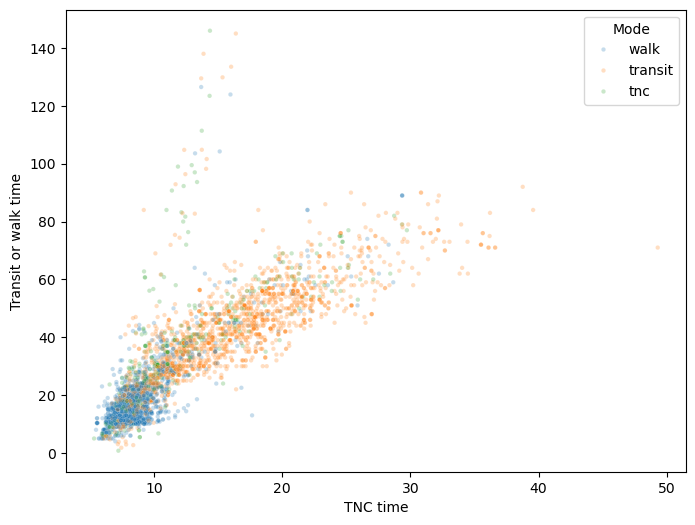

In [77]:
# some scatterplots

plt.figure(figsize=(8, 6))
sns.scatterplot(data=trip_linked, x='tnc_time', y='transit_or_walk_time', hue='mode', alpha=0.25, s=10)
plt.xlabel('TNC time')
plt.ylabel('Transit or walk time')
plt.legend(title='Mode')
plt.show()

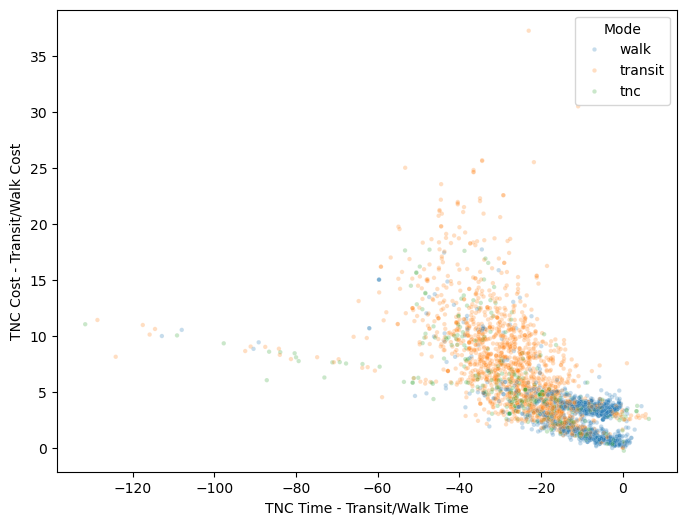

In [78]:
# some scatterplots

plt.figure(figsize=(8, 6))
sns.scatterplot(data=trip_linked, x='tnc_time_minus_transit_walk', y='tnc_cost_minus_transit_walk', hue='mode', alpha=0.25, s=10)
plt.xlabel('TNC Time - Transit/Walk Time')
plt.ylabel('TNC Cost - Transit/Walk Cost')
plt.legend(title='Mode')
plt.show()

In [79]:
# write to a file
trip_linked.to_csv('data/mode_choice_estimation_file.csv', index=False)